In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score 

In [13]:
df=pd.read_csv(r"C:\Users\HP\Downloads\Ice_cream selling data.csv")
df

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531
5,-3.455712,30.001138
6,-3.108440,22.635401
7,-3.081303,25.365022
8,-2.672461,19.226970
9,-2.652287,20.279679


In [23]:
X = df["Temperature (°C)"].to_frame()
y = df["Ice Cream Sales (units)"]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)


In [29]:
model_linear= LinearRegression()
model_linear.fit(X_train, y_train)
y_pred_linear= model_linear.predict(X_test)

In [33]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [35]:
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)
y_pred_poly = model_poly.predict(X_test_poly)

In [37]:
print("R2 Score:", r2_score(y_test, y_pred_poly))


R2 Score: 0.8430551371938841


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


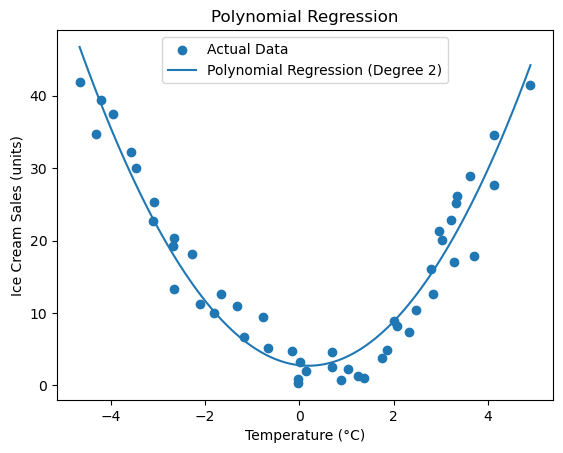

In [41]:
plt.scatter(X, y, label="Actual Data")

X_grid = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_grid_poly = poly.transform(X_grid)

plt.plot(X_grid,
         model_poly.predict(X_grid_poly),
         label="Polynomial Regression (Degree 2)")

plt.xlabel("Temperature (°C)")
plt.ylabel("Ice Cream Sales (units)")
plt.title("Polynomial Regression")
plt.legend()

plt.show()
